# E-commerce Analysis — 15 Business Questions

Fifteen questions answered against the Target/Olist e-commerce dataset, loaded into MySQL
by [`Ecommerce.ipynb`](Ecommerce.ipynb). Each query runs in MySQL; pandas, matplotlib and
seaborn handle the presentation.

The questions move from basic aggregation into CTEs and window functions
(`DENSE_RANK`, `LAG`, windowed `AVG`) in roughly increasing order of difficulty.

**Prerequisites:** run [`Ecommerce.ipynb`](Ecommerce.ipynb) first to create and populate the
`Ecommerce` database, and copy `.env.example` to `.env` with your own credentials.


## Setup

Imports and the database connection.


In [1]:
import os

import matplotlib.pyplot as plt
import mysql.connector
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

# Credentials are read from a local .env file that is never committed.
# Copy .env.example to .env and fill in your own values.
load_dotenv()

db = mysql.connector.connect(
    host=os.getenv("MYSQL_HOST", "localhost"),
    user=os.getenv("MYSQL_USER", "root"),
    password=os.getenv("MYSQL_PASSWORD"),
    database=os.getenv("MYSQL_DATABASE", "Ecommerce"),
)

cur = db.cursor()


### 1. Unique customer cities

`SELECT DISTINCT` over the `customers` table.


In [2]:
query = """ select distinct customer_city from customers """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["customer_city"])
df.head()

,customer_city
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


### 2. Orders placed in 2017

`COUNT()` filtered with MySQL's `YEAR()` on the purchase timestamp.


In [3]:
query = """ select count(order_id) from orders where year(order_purchase_timestamp) = 2017 """

cur.execute(query)

data = cur.fetchall()

"total orders placed in 2017 are", data[0][0]

('total orders placed in 2017 are', 45101)

### 3. Total sales per category

Three-table join (`products` → `order_items` → `payments`) aggregated with `GROUP BY`.


In [4]:
query = """ select upper(products.product_category) category, 
round(sum(payments.payment_value),2) sales
from products join order_items
on products.product_id = order_items.product_id
join payments 
on payments.order_id = order_items.order_id
group by category
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Category", "Sales"])
df

,Category,Sales
0,PERFUMERY,506738.66
1,FURNITURE DECORATION,1430176.39
2,TELEPHONY,486882.05
3,BED TABLE BATH,1712553.67
4,AUTOMOTIVE,852294.33
...,...,...
69,CDS MUSIC DVDS,1199.43
70,LA CUISINE,2913.53
71,FASHION CHILDREN'S CLOTHING,785.67
72,PC GAMER,2174.43


### 4. Share of orders paid in installments

Conditional aggregation with `CASE WHEN` inside `SUM()`. The test is `> 1`, since a single-shot payment is still recorded as one installment.


In [5]:
query = """ select (sum(case when payment_installments > 1 then 1
else 0 end))/count(*)*100 from payments """

cur.execute(query)

data = cur.fetchall()

"the percentage of orders that were paid in installments is", data[0][0]

('the percentage of orders that were paid in installments is',
 Decimal('49.4176'))

### 5. Customers per state

`GROUP BY` on state, sorted in pandas and plotted as a matplotlib bar chart.

Counted with `COUNT(DISTINCT customer_unique_id)`, not `COUNT(customer_id)`. In this dataset
`customer_id` is minted fresh for every order — there are 99,441 of them against 96,096 real
people — so counting it would count orders and call them customers.


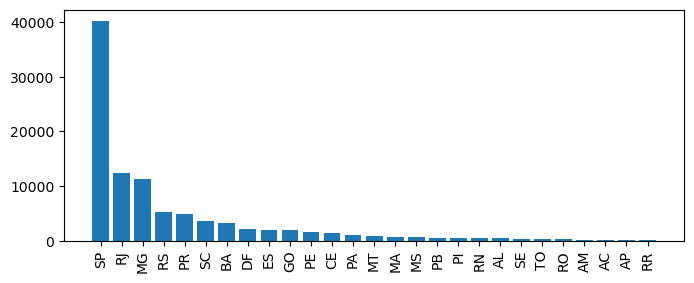

In [6]:
query = """ select customer_state, count(distinct customer_unique_id)
from customers group by customer_state
"""


cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["state", "customer_count"])
df = df.sort_values(by = "customer_count", ascending= False)

plt.figure(figsize = (8, 3))
plt.bar(df["state"], df["customer_count"])
plt.xticks(rotation = 90)
plt.show()

### 6. Orders per month in 2018

`MONTHNAME()` for the grouping, with an explicit month order passed to seaborn so the bars read chronologically rather than alphabetically.


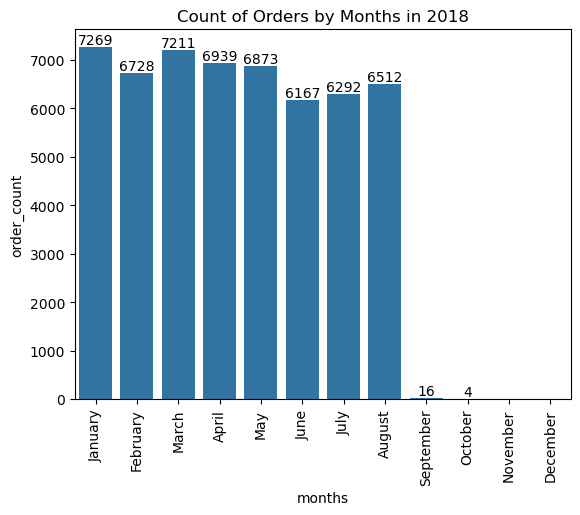

In [7]:
query = """ select monthname(order_purchase_timestamp) months, count(order_id) order_count
from orders where year(order_purchase_timestamp) = 2018
group by months
"""


cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["months", "order_count"])
o = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

ax = sns.barplot(x = df["months"], y = df["order_count"], data = df, order = o)
plt.xticks(rotation = 90)
ax.bar_label(ax.containers[0])
plt.title("Count of Orders by Months in 2018")

plt.show()

### 7. Average products per order, by customer city

A CTE counts line items per order, then the outer query averages those counts per city.


In [8]:
query = """with count_per_order as
(select orders.order_id, orders.customer_id, count(order_items.order_id) as oc
from orders join order_items
on orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id)

select customers.customer_city, round(avg(count_per_order.oc),2) average_orders
from customers join count_per_order
on customers.customer_id = count_per_order.customer_id
group by customers.customer_city order by average_orders desc
"""


cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["customer_city", "avg_products_per_order"])
df.head(10)


,customer_city,avg_products_per_order
0,padre carvalho,7.00
1,celso ramos,6.50
2,datas,6.00
3,candido godoi,6.00
4,matias olimpio,5.00
5,cidelandia,4.00
6,picarra,4.00
7,morro de sao paulo,4.00
8,teixeira soares,4.00
9,curralinho,4.00


### 8. Revenue share by product category

A scalar subquery in the `SELECT` list supplies the whole-dataset denominator for each category's percentage.


In [9]:
query = """ select upper(products.product_category) category,
round((sum(payments.payment_value)/(select sum(payment_value) from payments))*100,2) sales_percentage
from products join order_items
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by category order by sales_percentage desc """ 


cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Category", "percentage distribution"])
df



,Category,percentage distribution
0,BED TABLE BATH,10.70
1,HEALTH BEAUTY,10.35
2,COMPUTER ACCESSORIES,9.90
3,FURNITURE DECORATION,8.93
4,WATCHES PRESENT,8.93
...,...,...
69,HOUSE COMFORT 2,0.01
70,CDS MUSIC DVDS,0.01
71,PC GAMER,0.01
72,FASHION CHILDREN'S CLOTHING,0.00


### 9. Correlation between product price and purchase count

SQL aggregates category-level average price and order count; numpy's `corrcoef` measures the relationship between them.


In [10]:
query = """select products.product_category,
count(order_items.product_id),
round(avg(order_items.price),2)
from products join order_items
on products.product_id = order_items.product_id
group by products.product_category """


cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ["Category", "order_count", "price"])
df


arr1 = df["order_count"]
arr2 = df["price"]

a = np.corrcoef([arr1,arr2])
print("the correlation between price and the number of times a product has been purchased is", a[0][-1])


the correlation between price and the number of times a product has been purchased is -0.10631514167157562


### 10. Sellers ranked by revenue

`DENSE_RANK()` window function over summed payment value.


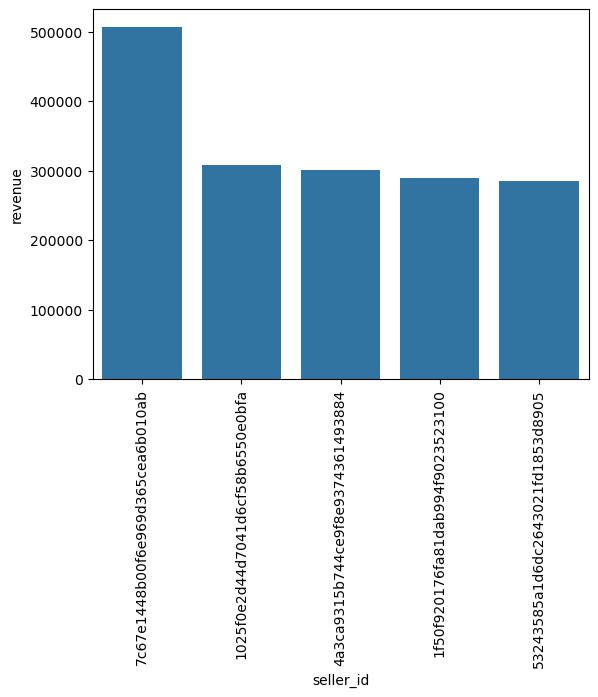

In [11]:
query = """ select *, dense_rank() over(order by revenue desc) as rn from
(select order_items.seller_id, sum(payments.payment_value)
revenue from order_items join payments
on order_items.order_id = payments.order_id
group by order_items.seller_id) as a """


cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["seller_id", "revenue", "rank"])
df = df.head()
sns.barplot(x = "seller_id", y = "revenue", data = df)
plt.xticks(rotation = 90)
plt.show()



### 11. Moving average of order value per customer

Windowed `AVG()` with `ROWS BETWEEN 2 PRECEDING AND CURRENT ROW`, partitioned per customer and ordered by purchase time.


In [12]:
query = """ select customer_id, order_purchase_timestamp,
avg(payment) over (partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from 
(select orders.customer_id, orders.order_purchase_timestamp,
payments.payment_value as payment
from payments join orders
on payments.order_id = orders.order_id) as a """


cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["customer_id", "order_purchase_timestamp", "moving_avg"])
df

,customer_id,order_purchase_timestamp,moving_avg
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.010002
...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.500000


### 12. Cumulative sales per month

Running total via `SUM() OVER (ORDER BY years, month_num)`.

Ordered on `MONTH()`, the month number, rather than on `MONTHNAME()`. Ordering by the name sorts
April, August, December, February — alphabetically — and a running total accumulated in that order
is meaningless while still looking perfectly well-formed.


In [13]:
query = """ select years, months, payment, sum(payment)
over(order by years, month_num) cumulative_sales from
(select year(orders.order_purchase_timestamp) as years,
monthname(orders.order_purchase_timestamp) as months,
month(orders.order_purchase_timestamp) as month_num,
round(sum(payments.payment_value),2) as payment from orders join payments
on orders.order_id = payments.order_id
group by years, months, month_num order by years, month_num) as a """


cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["year", "month", "monthly_sales", "cumulative_sales"])
df

,year,month,monthly_sales,cumulative_sales
0,2016,September,252.24,252.24
1,2016,October,59090.48,59342.72
2,2016,December,19.62,59362.34
3,2017,January,138488.04,197850.38
4,2017,February,291908.01,489758.39
5,2017,March,449863.60,939621.99
6,2017,April,417788.03,1357410.02
7,2017,May,592918.82,1950328.84
8,2017,June,511276.38,2461605.22
9,2017,July,592382.92,3053988.14


### 13. Year-over-year sales growth

`LAG()` pulls the prior year's total onto the same row, so the growth rate is a single expression.

Read the output with the dataset's coverage in mind: 2016 holds only a couple of months of orders,
which is why 2017's growth rate is in the thousands of percent, and 2018 stops in August, so its
figure is a partial year.


In [14]:
query = """ with a as(select year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value),2) as payment from orders join payments
on orders.order_id = payments.order_id
group by years order by years)

select years, (payment - lag(payment, 1) over(order by years))/
lag(payment, 1) over(order by years) * 100 from a """

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years", "yoy % growth"])
df

,years,yoy % growth
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


### 14. Customer retention rate

Share of customers who bought again within six months of their first order.

**The key matters more than the query here.** `customer_id` is a per-order surrogate key — a new
one for every order — so joining on it makes a repeat purchase structurally impossible to find and
returns 0% on any data. The real person is `customer_unique_id`; there are 3,345 repeat orders
hiding behind that distinction.

Two chained CTEs — first purchase per person, then anyone who bought again inside the window —
joined with a `LEFT JOIN` so people who never returned still count in the denominator.


In [15]:
query = """ with first_order as (
    select customers.customer_unique_id,
           min(orders.order_purchase_timestamp) as first_purchase
    from customers join orders
    on customers.customer_id = orders.customer_id
    group by customers.customer_unique_id),

repeat_buyers as (
    select distinct f.customer_unique_id
    from first_order f
    join customers on customers.customer_unique_id = f.customer_unique_id
    join orders on orders.customer_id = customers.customer_id
    where orders.order_purchase_timestamp > f.first_purchase
    and orders.order_purchase_timestamp < date_add(f.first_purchase, interval 6 month))

select round(100 * count(distinct r.customer_unique_id)
                 / count(distinct f.customer_unique_id), 2) as retention_pct
from first_order f
left join repeat_buyers r
on r.customer_unique_id = f.customer_unique_id """

cur.execute(query)
data = cur.fetchall()

data

[(Decimal('2.32'),)]

### 15. Top 3 customers by spend, per year

`DENSE_RANK()` with `PARTITION BY` year, filtered to the top three in the outer query.

Aggregated on `customer_unique_id` so a person's orders are summed together. Ranking on
`customer_id` would rank single orders and could never surface a repeat buyer.


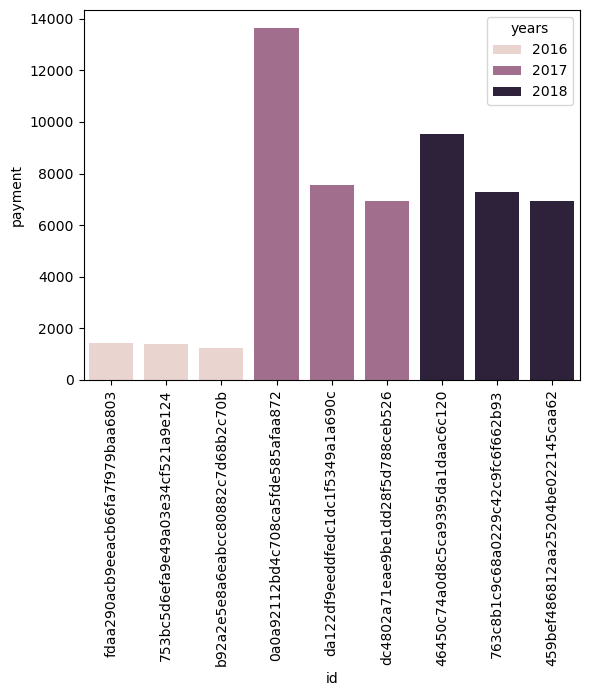

In [16]:
query = """ select years, customer_unique_id, payment, d_rank
from 
(select year(orders.order_purchase_timestamp) years,
customers.customer_unique_id,
sum(payments.payment_value) payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp)
order by sum(payments.payment_value) desc) d_rank 
from orders 
join customers on customers.customer_id = orders.customer_id
join payments on payments.order_id = orders.order_id 
group by year(orders.order_purchase_timestamp),
customers.customer_unique_id) as a
where d_rank <= 3 """

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years", "id", "payment", "rank"])
sns.barplot(x = "id", y = "payment", data = df, hue = "years")
plt.xticks(rotation = 90)
plt.show()
